# Tampa, Florida reached its all time record high on July 27 2025

As evident by [this](https://en.wikipedia.org/wiki/Weather_of_2025#Heat_waves_and_droughts) Wikipedia article.

This notebook explores data and methodology to identify patterns with regards to this record.

In [58]:
from datetime import datetime

import duckdb
import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import polars as pl
import seaborn as sns

from wpp import data, db
from wpp.utils import project_root

In [2]:
# config
sns.set_theme(style="ticks")
pl.Config.set_engine_affinity("streaming")

con = db.connect()

In [3]:
state_fips = '12'

In [4]:
db.create_block_group_table(state_fips)

In [5]:
db.create_wpp(state_fips)

In [6]:
db.create_pois(state_fips)

In [7]:
lf = con.sql("""
    SELECT * 
    FROM wpp_12
    WHERE DATE_RANGE_START BETWEEN '2025-05-01' AND '2025-08-31'
""").pl(lazy=True)
lf.head().collect()

BRAND,BUCKETED_DWELL_TIMES,CITY,CLOSE_DATE,DATE_RANGE_END,DATE_RANGE_START,DEVICE_TYPE,DISTANCE_FROM_HOME,FOOTPRINT_ID,ID_STORE,ISO_COUNTRY_CODE,IS_DISTRIBUTOR,LATITUDE,LOCATION_NAME,LONGITUDE,MEDIAN_DWELL,MSA_CODE,NAICS_CODE,OPEN_DATE,PERSISTENT_ID,PERSISTENT_ID_STORE,POI_CBG,POSTAL_CODE,REGION,RELATED_SAME_DAY_BRAND,RELATED_SAME_WEEK_BRAND,STREET_ADDRESS,SUB_CATEGORY,TICKER,TOP_CATEGORY,VISITOR_COUNTRY_OF_ORIGIN,VISITOR_COUNTS,VISITOR_DAYTIME_CBGS,VISITOR_HOME_AGGREGATION,VISITOR_HOME_CBGS,VISITS_BY_DAY,VISITS_BY_EACH_HOUR,VISIT_COUNTS
str,str,str,date,datetime[μs],datetime[μs],str,f64,"decimal[38,0]",str,str,bool,f64,str,f64,f64,"decimal[38,0]",str,date,str,str,str,str,str,str,str,str,str,str,str,str,"decimal[38,0]",str,str,str,str,str,"decimal[38,0]"
"""Retail Bakeries""",null,"""Madison""",2038-01-01,2025-05-11 00:00:00,2025-05-05 00:00:00,null,46.0,6581674416733963170,"""11339177""","""US""",false,30.461096,"""Retail Bakeries""",-83.425493,null,null,"""311811""",1970-01-01,"""A1_NAICS-311811""","""11339177""","""120791103022""","""32340""","""FL""",null,null,"""473 Sw Jeanette Cir""","""Retail Bakeries ""","""NAICS-311811""","""Bakeries and Tortilla Manufact…",null,12,"""{""120791103022"":12}""","""{""12079110302"":12}""","""{""120791103022"":12}""","""[0,0,0,0,0,0,12]""",null,12
"""Retail Bakeries""","""{""<5"":2220, ""5-20"":0, ""21-60"":…","""North Miami Beach""",2038-01-01,2025-05-11 00:00:00,2025-05-05 00:00:00,"""{""ios"":1786,""android"":257}""",7517.0,5864972953791294023,"""9828744""","""US""",false,25.91489,"""Retail Bakeries""",-80.163567,1.0,33100,"""311811""",1970-01-01,"""A1_NAICS-311811""","""9828744""","""120860002062""","""33162""","""FL""","""{""Mall"":1505,""Western Union"":1…","""{""Mall"":1997,""Western Union"":1…","""15120 W Dixie Hwy""","""Retail Bakeries ""","""NAICS-311811""","""Bakeries and Tortilla Manufact…","""{""US"":2043}""",2043,"""{""120860001092"":191,""120860002…","""{""12086000224"":453,""1208600020…","""{""120860002241"":174,""120860002…","""[368,166,416,415,309,261,297]""","""[0,0,0,0,13,39,89,102,26,13,13…",2232
"""Convenience Stores""","""{""<5"":998, ""5-20"":0, ""21-60"":0…","""Pompano Beach""",2038-01-01,2025-05-11 00:00:00,2025-05-05 00:00:00,"""{""ios"":616,""android"":382}""",2973.0,4250641210268957938,"""12065783""","""US""",false,26.219351,null,-80.104224,3.0,33100,"""447110""",2016-01-26,"""A1_CONV-A""","""12065783""","""120110309022""","""33062""","""FL""","""{""Sunshine Gasoline Distributo…","""{""Sunshine Gasoline Distributo…","""880 South Federal Highway""","""Gasoline Stations with Conveni…","""CONV-A""","""Gasoline Stations ""","""{""US"":998}""",998,"""{""120110309022"":416,""120110310…","""{""12011030902"":599,""1201103090…","""{""120110309022"":411,""120110311…","""[95,190,95,107,95,95,321]""","""[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0…",998
"""Hotels (except Casino Hotels) …","""{""<5"":1556, ""5-20"":0, ""21-60"":…","""Fort Walton Beach""",2038-01-01,2025-05-11 00:00:00,2025-05-05 00:00:00,"""{""ios"":1556}""",288729.0,8850522846978955937,"""11357512""","""US""",false,30.402479,"""Hotels (except Casino Hotels) …",-86.653084,1.0,18880,"""721110""",1970-01-01,"""A1_NAICS-721110""","""11357512""",null,"""32548""","""FL""","""{""Mall"":990,""Western Union"":84…","""{""Cardtronics"":1556,""Freshpet""…","""322 Miracle Strip Pkwy Sw""","""Hotels (except Casino Hotels) …","""NAICS-721110""","""Traveler Accommodation""","""{""US"":1556}""",1556,"""{""120910218022"":519,""401430067…",null,"""{""120910221001"":778,""120950170…","""[0,237,0,427,440,0,452]""","""[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0…",1556
"""Donna's Caribbean Restaurant""",null,"""Lauderdale Lakes""",2038-01-01,2025-05-11 00:00:00,2025-05-05 00:00:00,null,5711.0,6949105351529443033,"""7299445""","""US""",false,26.166972,"""Donna's Caribbean Restaurant""",-80.20249,7.0,33100,"""722511""",1970-01-01,"""A1_DONNA-A""","""7299445""","""120110503014""","""33319""","""FL""","""{""Mall"":123,""Moneygram"":82,""Wa…","""{""Mall"":143

<Axes: >

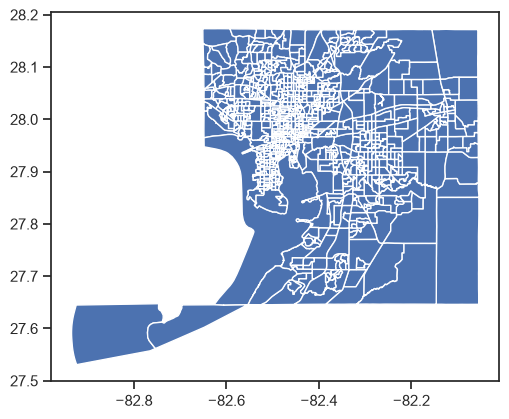

In [67]:
cb_df = con.sql("SELECT * FROM bg_12 WHERE STATEFP = '12' AND COUNTYFP = '057'").df()
cb_df["geom"] = cb_df["geom"].apply(bytes)
cb = gpd.GeoDataFrame(
    cb_df, 
    geometry=gpd.GeoSeries.from_wkb(cb_df["geom"]), 
    crs="EPSG:4326"
)
cb.plot()

In [68]:
pois = con.sql("""
    SELECT DISTINCT p.*
    FROM pois_12 AS p
    JOIN bg_12 AS boundary
      ON boundary.geom && ST_Point(p.LONGITUDE, p.LATITUDE)
     AND ST_Within(ST_Point(p.LONGITUDE, p.LATITUDE), boundary.geom)
    WHERE boundary.STATEFP = '12'
      AND boundary.COUNTYFP = '057'
""").pl().join(
    lf.group_by("ID_STORE").agg(
        pl.col("VISITOR_COUNTS").sum().cast(pl.Float64),
        pl.col("VISITOR_COUNTS").sum().log().cast(pl.Float64).alias("LOG_VISITOR_COUNTS")
    ).with_columns(
        pl.col("VISITOR_COUNTS")
            .qcut(10, labels=[str(i) for i in range(1, 11)])
            .cast(pl.Utf8).cast(pl.Int64).alias("VISITOR_DECILE")
    ).collect(),
    on="ID_STORE"
)
pois.head()

ID_STORE,BRAND,LOCATION_NAME,STREET_ADDRESS,POI_CBG,CITY,REGION,ISO_COUNTRY_CODE,TOP_CATEGORY,SUB_CATEGORY,OPEN_DATE,CLOSE_DATE,LONGITUDE,LATITUDE,VISITOR_COUNTS,LOG_VISITOR_COUNTS,VISITOR_DECILE
str,str,str,str,str,str,str,str,str,str,date,date,f64,f64,f64,f64,i64
"""9645718""","""Meat Markets""","""Meat Markets""","""4115 N Lynn Ave""","""120570023003""","""Tampa""","""FL""","""US""","""Specialty Food Stores ""","""Meat Markets """,1970-01-01,2038-01-01,-82.465112,27.983846,39042.0,10.572393,9
"""7987841""","""Convenience Stores""","""Convenience Stores""","""1110 N Florida Ave""","""120570051011""","""Tampa""","""FL""","""US""","""Grocery Stores ""","""Convenience Stores """,1970-01-01,2038-01-01,-82.459663,27.95355,19403.0,9.873183,8
"""10697524""","""Painting and Wall Covering Con…","""Painting and Wall Covering Con…","""4538 W Knox St""","""120570118024""","""Tampa""","""FL""","""US""","""Building Finishing Contractors""","""Painting and Wall Covering Con…",1970-01-01,2038-01-01,-82.523273,28.006318,20641.0,9.935035,8
"""1821719""","""Johnston & Murphy""","""Johnston & Murphy Group""","""International Plaza""","""120570026002""","""Tampa""","""FL""","""US""","""Shoe Stores ""","""Shoe Stores """,1970-01-01,2038-01-01,-82.520477,27.964427,12387.0,9.424403,7
"""3651391""","""Cooper Tire & Rubber""","""Cooper Tire & Rubber Company""","""4317 East Columbus Drive""","""120570036004""","""Tampa""","""FL""","""US""","""Rubber Product Manufacturing""","""Tire Manufacturing (except Ret…",1970-01-01,2038-01-01,-82.40864,27.966161,5423.0,8.598404,5


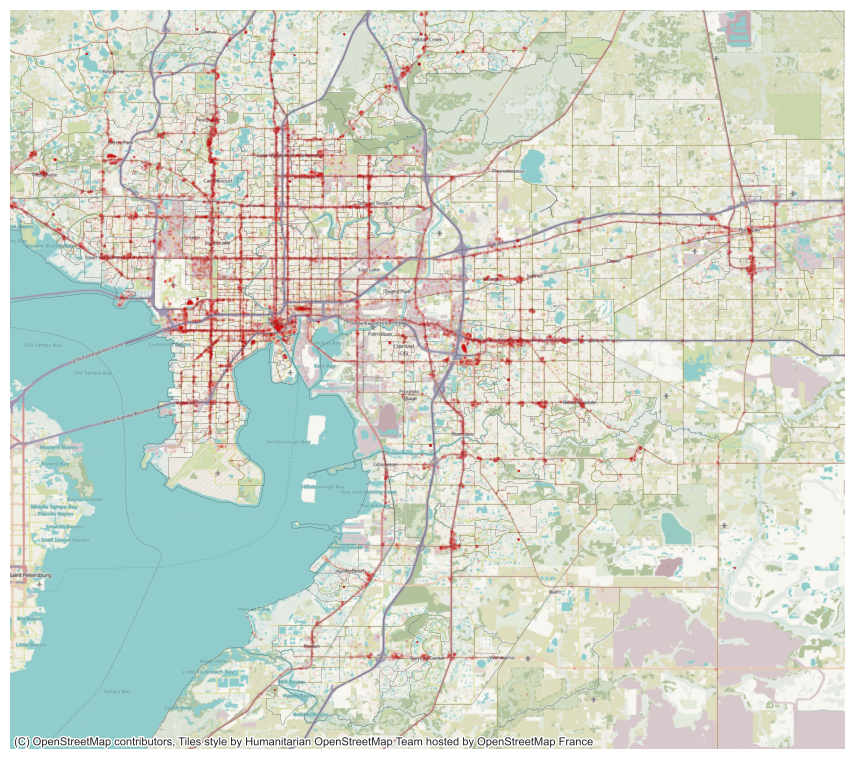

In [69]:
fig_scale = 2
fig, ax = plt.subplots(figsize=(6.4*fig_scale, 4.8*fig_scale))
cb.boundary.plot(ax=ax, color="#444", linewidth=0.1)
sns.scatterplot(
    pois, x="LONGITUDE", y="LATITUDE",
    color="#c00", size="VISITOR_DECILE", sizes=(1, 5),
    alpha=.1, ax=ax, legend=False
)
ax.set_xlim(pois["LONGITUDE"].min(), pois["LONGITUDE"].max())
ax.set_ylim(pois["LATITUDE"].min(), pois["LATITUDE"].max())
cx.add_basemap(ax, crs="EPSG:4326", zoom=12)
ax.set_axis_off()
ax.set_aspect("equal")

In [72]:
visits_by_date = con.sql("""
    WITH x AS (
        SELECT 
            DATE_RANGE_START, 
            from_json(VISITS_BY_DAY, '["INTEGER"]')::INTEGER[7] AS VISITS_BY_DAY
        FROM wpp_12
        WHERE VISITS_BY_DAY IS NOT NULL
          AND DATE_RANGE_START BETWEEN '2025-05-01' AND '2025-08-31'
    ), y AS (
        SELECT
            DATE_RANGE_START::DATE AS DATE,
            unnest(VISITS_BY_DAY) AS VISITS,
            generate_subscripts(VISITS_BY_DAY, 1) AS DAY
        FROM x
    )
    SELECT 
        (DATE + INTERVAL (DAY - 1) DAY)::DATE AS DATE,
        SUM(VISITS) AS VISITS
    FROM y
    GROUP BY 1
    ORDER BY 1
""").pl().with_columns(
    pl.col("VISITS").rolling_mean(window_size=7).alias("VISITS_ROLLING")
)
visits_by_date.head()visits_by_date = con.sql("""
    WITH x AS (
        SELECT 
            DATE_RANGE_START, 
            from_json(VISITS_BY_DAY, '["INTEGER"]')::INTEGER[7] AS VISITS_BY_DAY
        FROM wpp_12
        WHERE VISITS_BY_DAY IS NOT NULL
          AND DATE_RANGE_START BETWEEN '2025-05-01' AND '2025-08-31'
    ), y AS (
        SELECT
            DATE_RANGE_START::DATE AS DATE,
            unnest(VISITS_BY_DAY) AS VISITS,
            generate_subscripts(VISITS_BY_DAY, 1) AS DAY
        FROM x
    )
    SELECT 
        (DATE + INTERVAL (DAY - 1) DAY)::DATE AS DATE,
        SUM(VISITS) AS VISITS
    FROM y
    GROUP BY 1
    ORDER BY 1
""").pl().with_columns(
    pl.col("VISITS").rolling_mean(window_size=7).alias("VISITS_ROLLING")
)
visits_by_date.head()

DATE,VISITS,VISITS_ROLLING
date,"decimal[38,0]",f64
2025-05-05,155226626,null
2025-05-06,155303916,null
2025-05-07,161262357,null
2025-05-08,165669654,null
2025-05-09,189483922,null


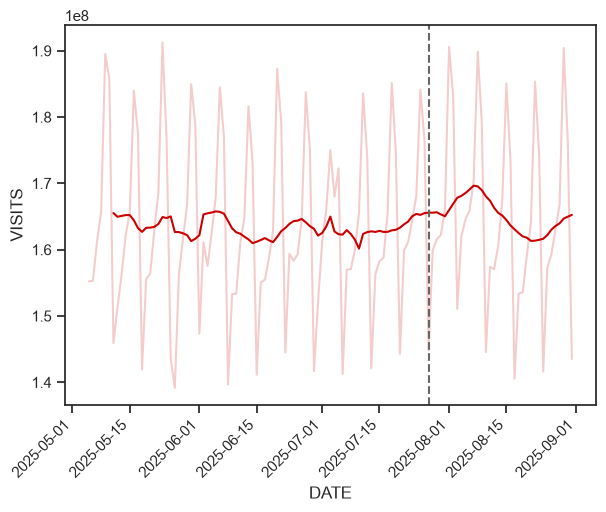

In [78]:
heatwave_date = datetime.fromisoformat("2025-07-27")

x = visits_by_date["DATE"]
y = visits_by_date["VISITS"]
y_r = visits_by_date["VISITS_ROLLING"]

fig, ax = plt.subplots()
sns.lineplot(x=x, y=y, ax=ax, alpha=0.2, color="#c00")
sns.lineplot(x=x, y=y_r, color="#c00", ax=ax)
ax.axvline(heatwave_date, color="#666", linestyle="--")

fig.tight_layout()
ax.tick_params("x", rotation=45, rotation_mode="xtick")

In [98]:
visits_by_date = con.sql("""
    WITH x AS (
        SELECT 
            DATE_RANGE_START, 
            COUNTYFP,
            from_json(VISITS_BY_DAY, '["INTEGER"]')::INTEGER[7] AS VISITS_BY_DAY
        FROM wpp_12
        JOIN bg_12 ON bg_12.GEOID = wpp_12.POI_CBG
        WHERE VISITS_BY_DAY IS NOT NULL
          AND DATE_RANGE_START BETWEEN '2025-05-01' AND '2025-08-31'
    ), y AS (
        SELECT
            DATE_RANGE_START::DATE AS DATE,
            COUNTYFP,
            unnest(VISITS_BY_DAY) AS VISITS,
            generate_subscripts(VISITS_BY_DAY, 1) AS DAY
        FROM x
    )
    SELECT 
        (DATE + INTERVAL (DAY - 1) DAY)::DATE AS DATE,
        COUNTYFP,
        SUM(VISITS) AS VISITS
    FROM y
    GROUP BY 1, 2
    ORDER BY 1, 2
""").pl().with_columns(
    (pl.col("VISITS") / pl.col("VISITS").mean().over("COUNTYFP")).alias("VISITS_NORMALIZED")
)
visits_by_date.head()

DATE,COUNTYFP,VISITS,VISITS_NORMALIZED
date,str,"decimal[38,0]",f64
2025-05-05,"""001""",1296785,0.936252
2025-05-05,"""003""",103800,0.930859
2025-05-05,"""005""",2203570,0.793858
2025-05-05,"""007""",156523,0.956858
2025-05-05,"""009""",3959379,0.935267


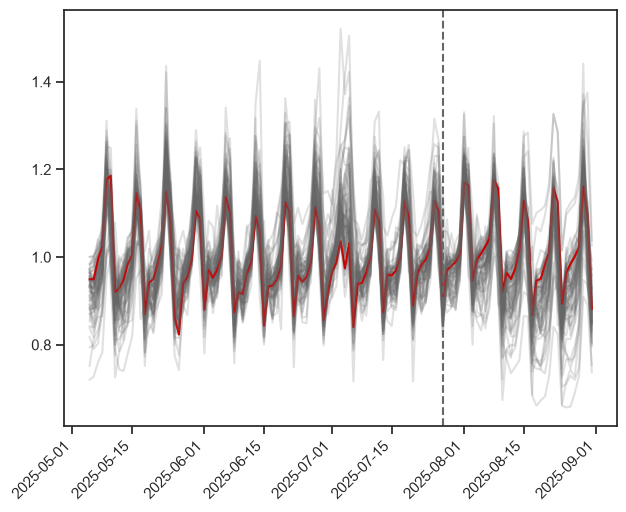

In [129]:
heatwave_date = datetime.fromisoformat("2025-07-27")

fig, ax = plt.subplots()
for county, group in visits_by_date.group_by("COUNTYFP"):
    color = "#666" if county[0] != "057" else "#c00"
    alpha = 0.2 if county[0] != "057" else 1
    ax.plot(
        group["DATE"],
        group["VISITS_NORMALIZED"],
        color=color,
        alpha=alpha,
    )
ax.axvline(heatwave_date, color="#666", linestyle="--")

fig.tight_layout()
ax.tick_params("x", rotation=45, rotation_mode="xtick")

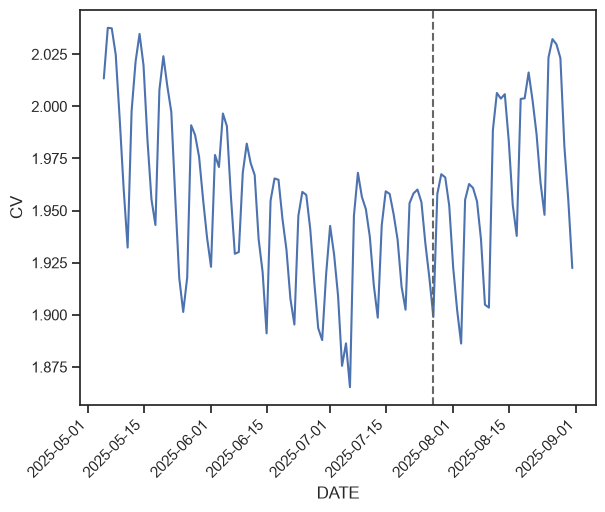

In [123]:
heatwave_date = datetime.fromisoformat("2025-07-27")
std = visits_by_date.group_by("DATE").agg(
    pl.col("VISITS").std().alias("VISITS_STD"),
    (pl.col("VISITS").std() / pl.col("VISITS").mean()).alias("CV")
)

fig, ax = plt.subplots()
sns.lineplot(
    std,
    x="DATE",
    y="CV",
)
ax.axvline(heatwave_date, color="#666", linestyle="--")

fig.tight_layout()
ax.tick_params("x", rotation=45, rotation_mode="xtick")